# 13_01 Context Reconstruction Validation

현재 CSR Runtime의 `통화 원문 → Event/Feature → ML 위험도 → 구조화 Context → LLM Case Brief → 저장 직전 projection`을 실제 production import로 검증한다. 운영 코드는 수정하지 않으며 운영 DB에는 쓰지 않는다.

평가 우선순위: **Contradiction > Critical Fact Recall > Hallucination > Feature Extraction > Semantic Similarity**

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RUNNER_DIR = ROOT / 'tests' / 'context_reconstruction'
if str(RUNNER_DIR) not in sys.path:
    sys.path.insert(0, str(RUNNER_DIR))
import run_validation as rv
print('Repository:', ROOT)
print('Production key configured:', bool(rv.os.getenv('OPENAI_API_KEY')))

Repository: C:\Users\mbc\Documents\GitHub\AIXTeamProject2
Production key configured: True


## 1. Runtime Feature Inventory

아래 수치는 문서가 아니라 `features_from_events([])`, 실제 pkl의 `model_features`, Pydantic `CaseContextFeatures` 직렬화 구조에서 계산한다.

In [2]:
inventory = rv.build_inventory()
counts = pd.DataFrame([
    {'계층': 'A. Extractor 후보', '개수': int((inventory['Extractor 후보'] == 'O').sum()), 'LLM 직접 입력': 'X'},
    {'계층': 'B. ML selected', '개수': int((inventory['ML 입력 여부'] == 'O').sum()), 'LLM 직접 입력': 'X'},
    {'계층': 'C. case_context_features schema', '개수': len(rv.CONTEXT_FIELDS), 'LLM 직접 입력': 'O'},
    {'계층': 'C-보조. signals[] 속성', '개수': len(rv.SIGNAL_FIELDS), 'LLM 직접 입력': 'O'},
])
display(counts)
display(inventory[inventory['LLM 입력 여부'] == 'O'])

,계층,개수,LLM 직접 입력
0,A. Extractor 후보,152,X
1,B. ML selected,23,X
2,C. case_context_features schema,12,O
3,C-보조. signals[] 속성,7,O


,대분류,실제 Feature/Field명,한국어 의미,값 형태,어떤 정보인가,Extractor 후보,ML 입력 여부,LLM 입력 여부,전달 규칙,자연어 생성 시 사용 예
152,LLM 구조화 Context,case_context_features.claimed_actor_types,사칭 주체 코드 목록,list[str],ROLE_ 관찰 중 부인되지 않은 코드,Context Extractor,X,O,활성 코드만,사칭 주체 코드 목록을 근거로 요약·주장·요구를 생성
153,LLM 구조화 Context,case_context_features.claim_codes,범죄자 주장 코드 목록,list[str],CLAIM_ 관찰 중 부인되지 않은 코드,Context Extractor,X,O,활성 코드만,범죄자 주장 코드 목록을 근거로 요약·주장·요구를 생성
154,LLM 구조화 Context,case_context_features.requested_action_codes,행동 요구 코드 목록,list[str],REQUEST_ 관찰 중 부인되지 않은 코드,Context Extractor,X,O,활성 코드만,행동 요구 코드 목록을 근거로 요약·주장·요구를 생성
155,LLM 구조화 Context,case_context_features.manipulation_tactic_codes,심리 조작 코드 목록,list[str],TACTIC_ 관찰 중 부인되지 않은 코드,Context Extractor,X,O,활성 코드만,심리 조작 코드 목록을 근거로 요약·주장·요구를 생성
156,LLM 구조화 Context,case_context_features.exposure_risk_codes,노출 위험 코드 목록,list[str],독립 Extractor 경로에서는 기본 빈 목록,Context Extractor,X,O,빈 목록도 전달,노출 위험 코드 목록을 근거로 요약·주장·요구를 생성
157,LLM 구조화 Context,case_context_features.amount_values_krw,금액 목록(원),list[float],독립 Extractor 경로에서는 기본 빈 목록,Context Extractor,X,O,빈 목록도 전달,금액 목록(원)을 근거로 요약·주장·요구를 생성
158,LLM 구조화 Context,case_context_features.chronology,턴별 관찰 연대기,list[str],T{turn}:{status}:{code},Context Extractor,X,O,활성·부인 관찰,턴별 관찰 연대기을 근거로 요약·주장·요구를 생성
159,LLM 구조화 Context,case_context_features.unknown_fields,추가 확인 필요 필드,list[str],독립 Extractor 경로에서는 기본 빈 목록,Context Extractor,X,O,빈 목록도 전달,추가 확인 필요 필드을 근거로 요약·주장·요구를 생성
160,LLM 구조화 Context,case_context_features.source,구조화 입력 출처,string,항상 STRUCTURED_CONTEXT_FEATURES_ONLY,Context Extractor,X,O,항상 전달,구조화 입력 출처을 근거로 요약·주장·요구를 생성
161,LLM 구조화 Context,case_context_features.schema_version,Context 스키마 버전,string,현재 case_context_features.v2,Context Extractor,X,O,항상 전달,Context 스키마 버전을 근거로 요약·주장·요구를 생성


## 2. 테스트 시나리오와 Ground Truth

Frontend의 기존 5개 예시를 재사용하고, 사칭·송금·현금 전달·원격 앱·인증정보·개인정보·긴급성·공포·고립·복수 금액·피해 완료·부인·정상 경계 사례를 추가했다.

In [3]:
samples = json.loads(rv.SAMPLES_PATH.read_text(encoding='utf-8'))
print('총 시나리오:', len(samples))
display(pd.DataFrame([{
    'ID': s['sample_id'], '카테고리': s['category'], '출처': s['source'],
    'GT Context code 수': len(s['expected_context_codes']),
    'GT 핵심 사실 수': len(s['critical_facts']), '금액': s.get('amounts_krw', [])
} for s in samples]))

총 시나리오: 30


,ID,카테고리,출처,GT Context code 수,GT 핵심 사실 수,금액
0,S01,검찰 사칭·송금·고립,MVP_v3/frontend/src/pages/HomePage.tsx,11,6,[]
1,S02,카드사 사칭·OTP·환불 송금,MVP_v3/frontend/src/pages/HomePage.tsx,9,6,[]
2,S03,정상 카드 분실 상담,MVP_v3/frontend/src/pages/HomePage.tsx,1,2,[]
3,S04,정상 주택담보대출 상담,MVP_v3/frontend/src/pages/HomePage.tsx,1,3,[]
4,S05,정상 자동이체 변경,MVP_v3/frontend/src/pages/HomePage.tsx,1,2,[]
5,S06,가족 사칭·긴급 송금,validation-authored,5,4,[1200000]
6,S07,고객지원 사칭·원격제어 앱,validation-authored,3,4,[]
7,S08,경찰 사칭·현금 전달,validation-authored,5,5,[5000000]
8,S09,대출업체 사칭·상환 요구,validation-authored,5,5,[8000000]
9,S10,은행 사칭·계좌 검증·개인정보,validation-authored,6,5,[]


## 3. 실제 Production Pipeline 실행

`DiagnosisService()`를 그대로 생성해 실제 OpenAI event extractor, 독립 context extractor, Window Feature 계산, 실제 Logistic pkl 예측, Context LLM을 호출한다. `--force`와 동일하게 매번 새로 실행한다. 각 결과에는 A~G 산출물과 저장 직전 privacy projection이 포함된다.

In [4]:
FORCE_RUNTIME = False  # True로 바꾸면 30건 production API를 다시 호출
CONCURRENCY = 2
LIMIT = None

In [5]:
frame, records = rv.run(force=FORCE_RUNTIME, limit=LIMIT, concurrency=CONCURRENCY)
display(frame)

,sample_id,category,status,runtime_seconds,risk_level,risk_score,model_label,active_extractor_features,ml_selected_features,ml_zero_features,...,contradiction_count,hallucination_count,fact_precision,amount_preservation,semantic_similarity,embedding_model,missing_critical_facts,contradicted_forbidden_facts,hallucinated_context_codes,unsupported_amounts_krw
0,S01,검찰 사칭·송금·고립,OK,15.351419,NORMAL,87.205815,NORMAL,7,23,20,...,0,1,0.875000,True,0.580378,text-embedding-3-small,오늘 또는 즉시 처리 | 가족·은행에 알리지 말라는 고립 | 통화 유지 요구,,REQUEST_AUTH_INFO,
1,S02,카드사 사칭·OTP·환불 송금,OK,11.088610,HIGH,95.357322,PHISHING,17,23,15,...,0,4,0.428571,True,0.580685,text-embedding-3-small,환불 명목 송금 요구 | 은행 문의 차단 | 통화 유지,,CLAIM_CRIME_INVOLVEMENT | CUSTOMER_INSTALLED_A...,
2,S03,정상 카드 분실 상담,OK,11.663231,HIGH,99.008334,PHISHING,16,23,17,...,0,3,0.250000,True,0.532853,text-embedding-3-small,정상 카드 분실 상담 | 공식 앱 확인,,CLAIM_CRIME_INVOLVEMENT | CLAIM_DEVICE_BROKEN ...,
3,S04,정상 주택담보대출 상담,OK,10.906879,HIGH,98.642782,PHISHING,11,23,18,...,1,3,0.000000,True,0.383621,text-embedding-3-small,정상 대출 상담 | 공식 앱 | 영업점 방문,기관 사칭,CLAIM_CRIME_INVOLVEMENT | NORMAL_DAILY_CALL | ...,
4,S05,정상 자동이체 변경,OK,11.552901,NORMAL,68.825270,NORMAL,5,23,20,...,2,4,0.000000,True,0.441759,text-embedding-3-small,은행 앱 알림,범죄 연루 | 사기 송금,CLAIM_CRIME_INVOLVEMENT | NORMAL_DAILY_CALL | ...,
5,S06,가족 사칭·긴급 송금,OK,9.916429,HIGH,99.107601,PHISHING,11,23,20,...,0,4,0.428571,True,0.563082,text-embedding-3-small,120만원 송금 요구 | 긴급성,,CLAIM_CRIME_INVOLVEMENT | CLAIM_LOAN_APPROVAL ...,
6,S07,고객지원 사칭·원격제어 앱,OK,10.651558,HIGH,99.976128,PHISHING,9,23,18,...,0,4,0.200000,True,0.555217,text-embedding-3-small,고객지원 사칭 | 화면 공유 | 통화 유지,,CLAIM_CRIME_INVOLVEMENT | CLAIM_DEVICE_BROKEN ...,
7,S08,경찰 사칭·현금 전달,OK,10.763925,HIGH,99.942778,PHISHING,13,23,17,...,0,2,0.600000,False,0.511352,text-embedding-3-small,현금 500만원 인출·전달 요구 | 체포 위협 | 오늘 기한,,CUSTOMER_NOT_TRANSFERRED | REQUEST_TRANSFER,
8,S09,대출업체 사칭·상환 요구,OK,8.568451,HIGH,98.642782,PHISHING,11,23,18,...,0,2,0.666667,False,0.636852,text-embedding-3-small,800만원,,CLAIM_CRIME_INVOLVEMENT | DEADLINE_IMMEDIATE,
9,S10,은행 사칭·계좌 검증·개인정보,OK,8.723764,NORMAL,4.311804,NORMAL,7,23,19,...,0,1,0.500000,True,0.497058,text-embedding-3-small,은행 사칭 | 주민등록번호·계좌번호 요구 | 거래 정지 위협 | 즉시 요구,,CLAIM_CRIME_INVOLVEMENT,


## 4. 품질 지표

Feature 평가는 GT 핵심 active 신호와 representative window의 실제 active 신호를 비교한다. Semantic similarity는 한국어 참조 Brief와 생성 Brief를 OpenAI `text-embedding-3-small`(환경에서 override 가능)로 임베딩한 cosine similarity다. 사실 보존·모순·환각은 고정 규칙 감사이므로 반복 실행 시 평가 규칙 자체는 변하지 않는다.

In [6]:
ok = frame[frame.status == 'OK']
metric_columns = ['context_feature_recall','context_feature_precision','numeric_feature_recall','numeric_feature_precision','entity_recall','amount_recall','critical_fact_recall','fact_precision','semantic_similarity','hallucination_count','contradiction_count']
display(ok[metric_columns].apply(pd.to_numeric, errors='coerce').agg(['mean','min','max']).T)

,mean,min,max
context_feature_recall,0.414487,0.000000,1.000000
context_feature_precision,0.463849,0.000000,1.000000
numeric_feature_recall,0.235860,0.000000,0.600000
numeric_feature_precision,0.449524,0.000000,1.000000
entity_recall,0.766667,0.000000,1.000000
amount_recall,0.966667,0.000000,1.000000
critical_fact_recall,0.313730,0.000000,1.000000
fact_precision,0.347460,0.000000,1.000000
semantic_similarity,0.467911,0.185958,0.636852
hallucination_count,2.533333,0.000000,5.000000


## 5. 대표 샘플 상세 비교

In [7]:
if len(ok):
    chosen = pd.concat([ok.nsmallest(min(3, len(ok)), 'critical_fact_recall'), ok.nlargest(min(2, len(ok)), 'critical_fact_recall')]).drop_duplicates('sample_id').head(5)
    for sample_id in chosen.sample_id:
        r = next(item for item in records if item['sample_id'] == sample_id)
        display(Markdown(f"### {sample_id} — {r['category']}"))
        display(pd.DataFrame({
            '항목': ['Ground Truth', '구조화 Context', '생성 Brief', '누락', '모순'],
            '내용': [', '.join(r['ground_truth']['critical_facts']), ', '.join(r['C_active_context_codes']), r['F_generated_case_brief'], ', '.join(r['G_metrics']['critical_facts_missing']) or '없음', ', '.join(r['G_metrics']['contradicted_forbidden_facts']) or '없음']
        }))

### S03 — 정상 카드 분실 상담

,항목,내용
0,Ground Truth,"정상 카드 분실 상담, 공식 앱 확인"
1,구조화 Context,"CLAIM_DEVICE_BROKEN, CLAIM_UNAUTHORIZED_PAYMEN..."
2,생성 Brief,"해당 사건은 카드 관련 문제를 주장하는 것으로, 주요 요청은 기기 고장과 비인가 결..."
3,누락,"정상 카드 분실 상담, 공식 앱 확인"
4,모순,없음


### S04 — 정상 주택담보대출 상담

,항목,내용
0,Ground Truth,"정상 대출 상담, 공식 앱, 영업점 방문"
1,구조화 Context,NORMAL_DAILY_CALL
2,생성 Brief,금융 기관을 사칭하는 사건이 발생했습니다. 여러 차례의 고위험 요청이 있었습니다. ...
3,누락,"정상 대출 상담, 공식 앱, 영업점 방문"
4,모순,기관 사칭


### S14 — 송금 부인·개인정보 제공

,항목,내용
0,Ground Truth,"은행 직원 사칭, 송금 요구, 송금하지 않음, 개인정보 제공함"
1,구조화 Context,"CLAIM_ACCOUNT_VERIFICATION, REQUEST_TRANSFER"
2,생성 Brief,해당 사건은 금융기관을 사칭하며 민감한 개인정보를 요구하는 것으로 의심되는 사례입니다.
3,누락,"은행 직원 사칭, 송금 요구, 송금하지 않음, 개인정보 제공함"
4,모순,없음


### S12 — 인증번호 단독 요구

,항목,내용
0,Ground Truth,인증번호 요구
1,구조화 Context,REQUEST_AUTH_INFO
2,생성 Brief,Psy Strategy와 관련된 신호가 발생했습니다. 요청된 행동은 인증 정보 요청...
3,누락,없음
4,모순,없음


### S09 — 대출업체 사칭·상환 요구

,항목,내용
0,Ground Truth,"대출업체 사칭, 대환대출 승인 주장, 기존 대출 상환 명목, 800만원, 오늘 기한"
1,구조화 Context,"CLAIM_LOAN_APPROVAL, DEADLINE_TODAY, PURPOSE_L..."
2,생성 Brief,"이 사건은 금융 기관을 사칭한 대출 승인을 요구하는 신호가 발견되었으며, 대출 상환..."
3,누락,800만원
4,모순,없음


## 6. 시각화

### 01_feature_recall_by_sample

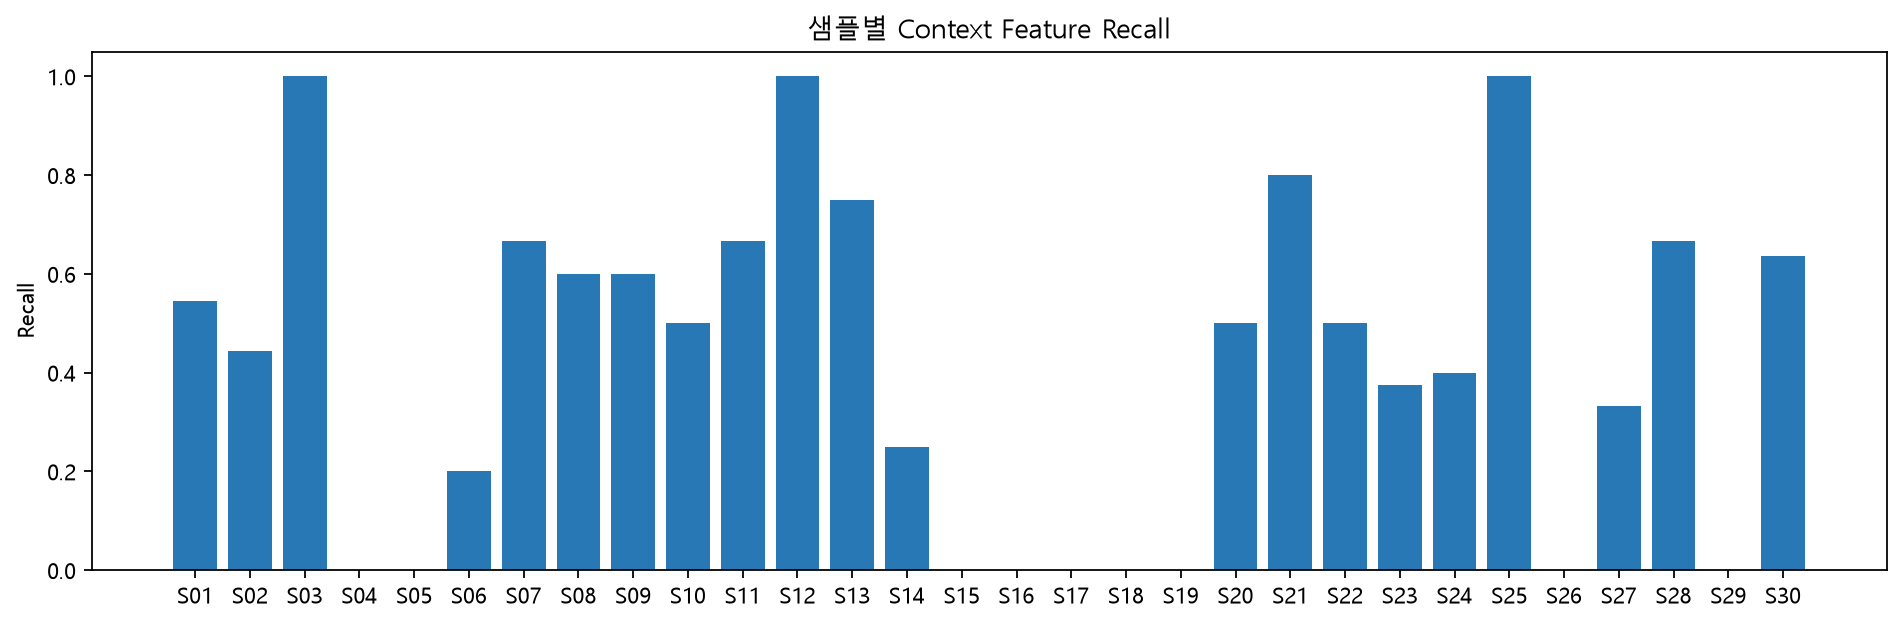

### 02_feature_recall_by_category

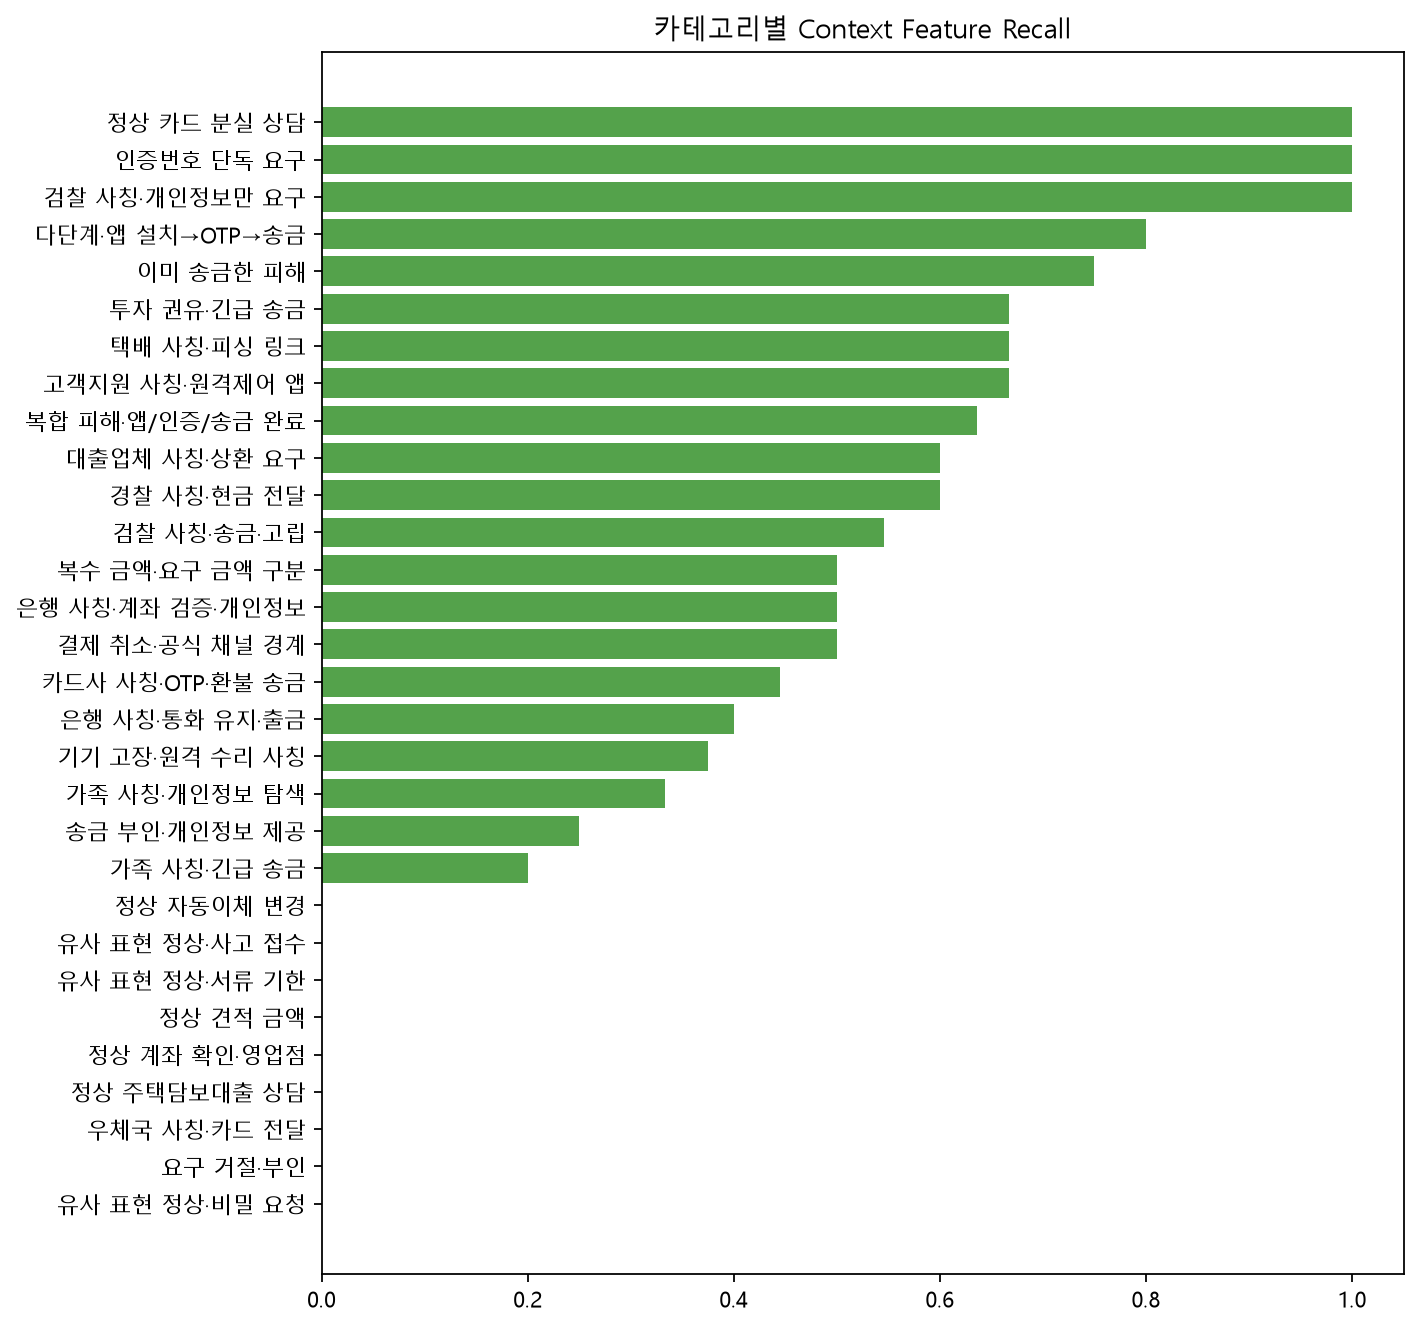

### 03_frequently_missing_facts

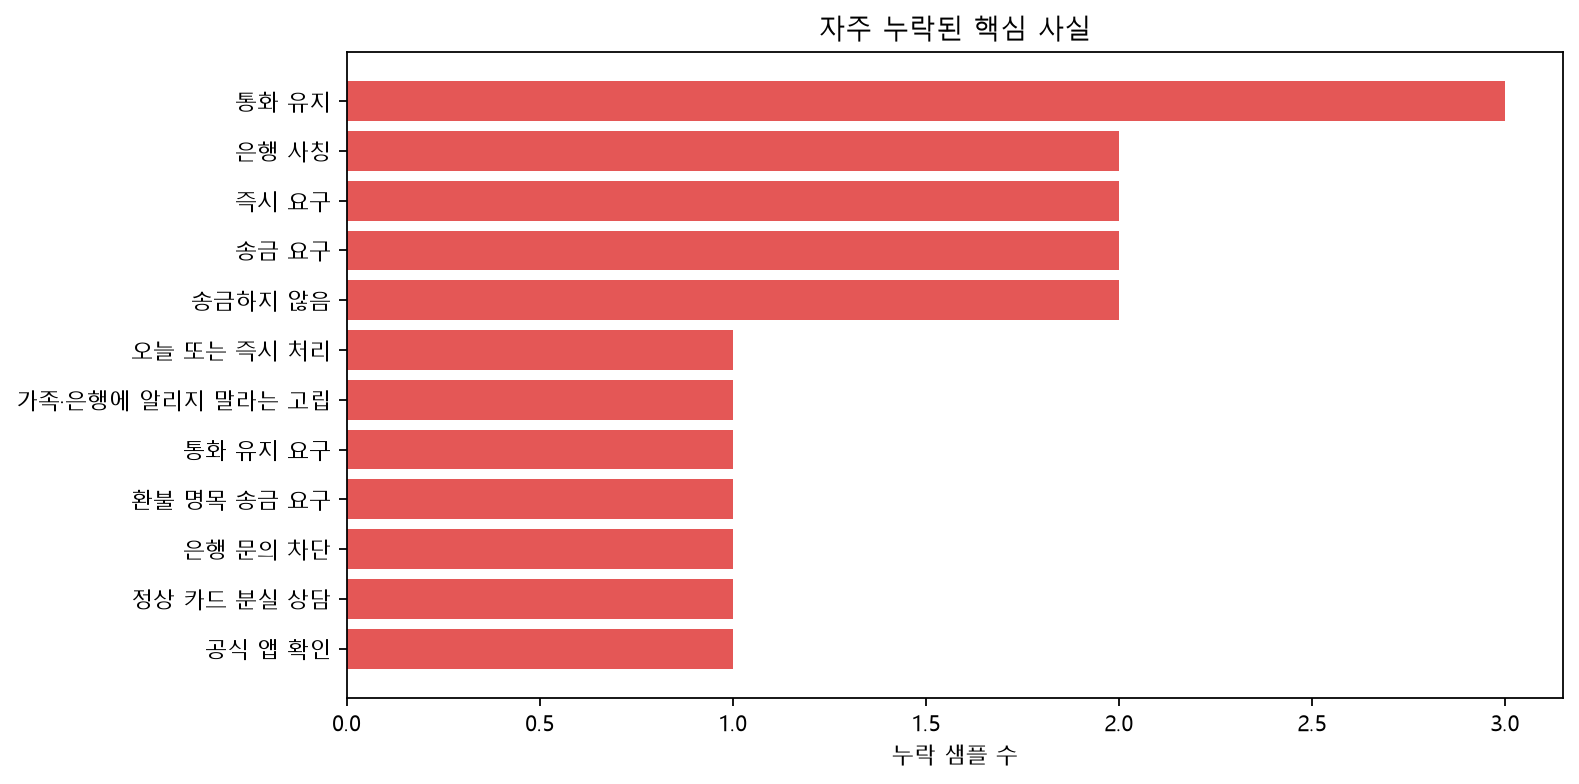

### 04_context_vs_brief

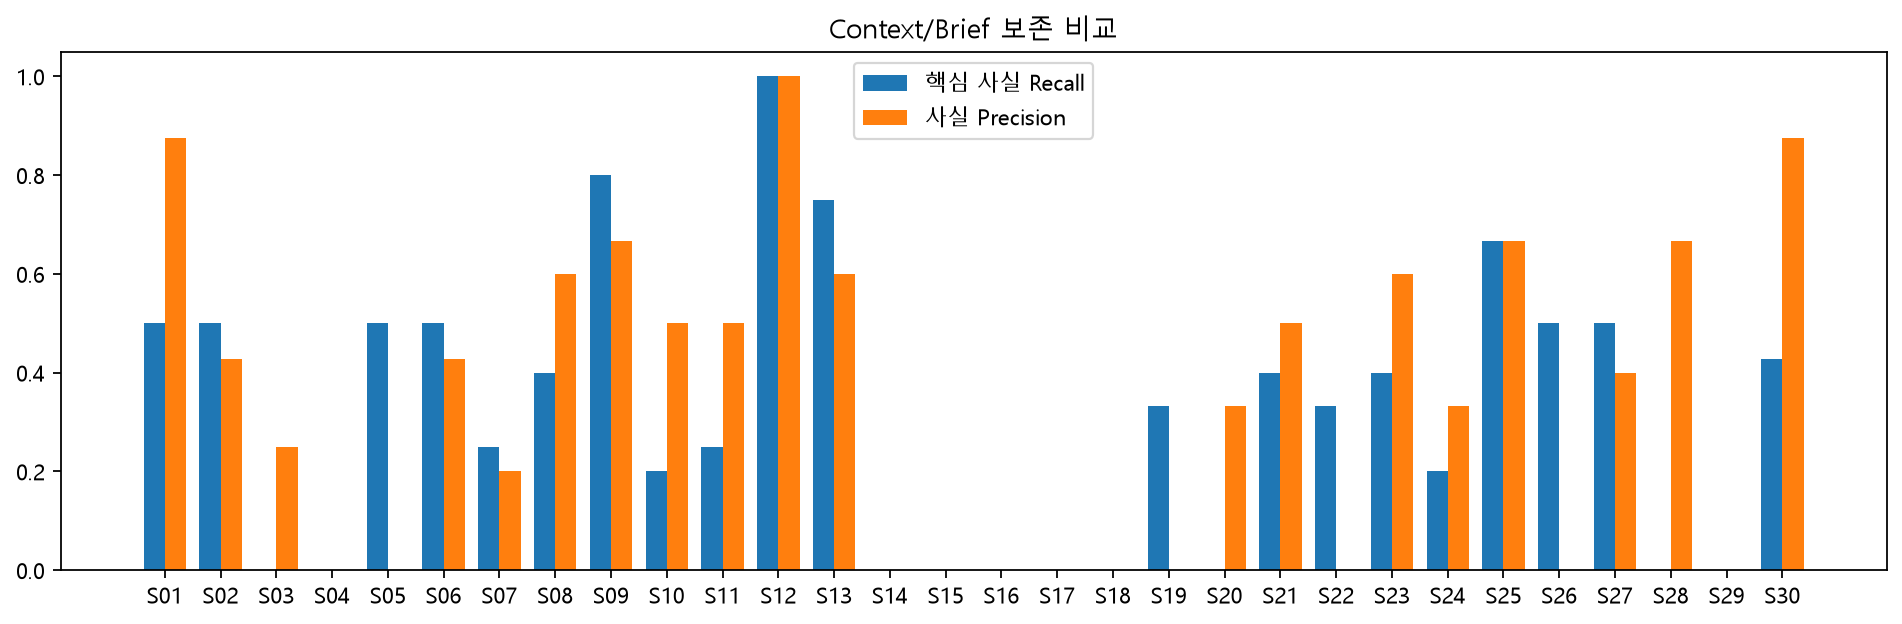

### 05_hallucination_by_category

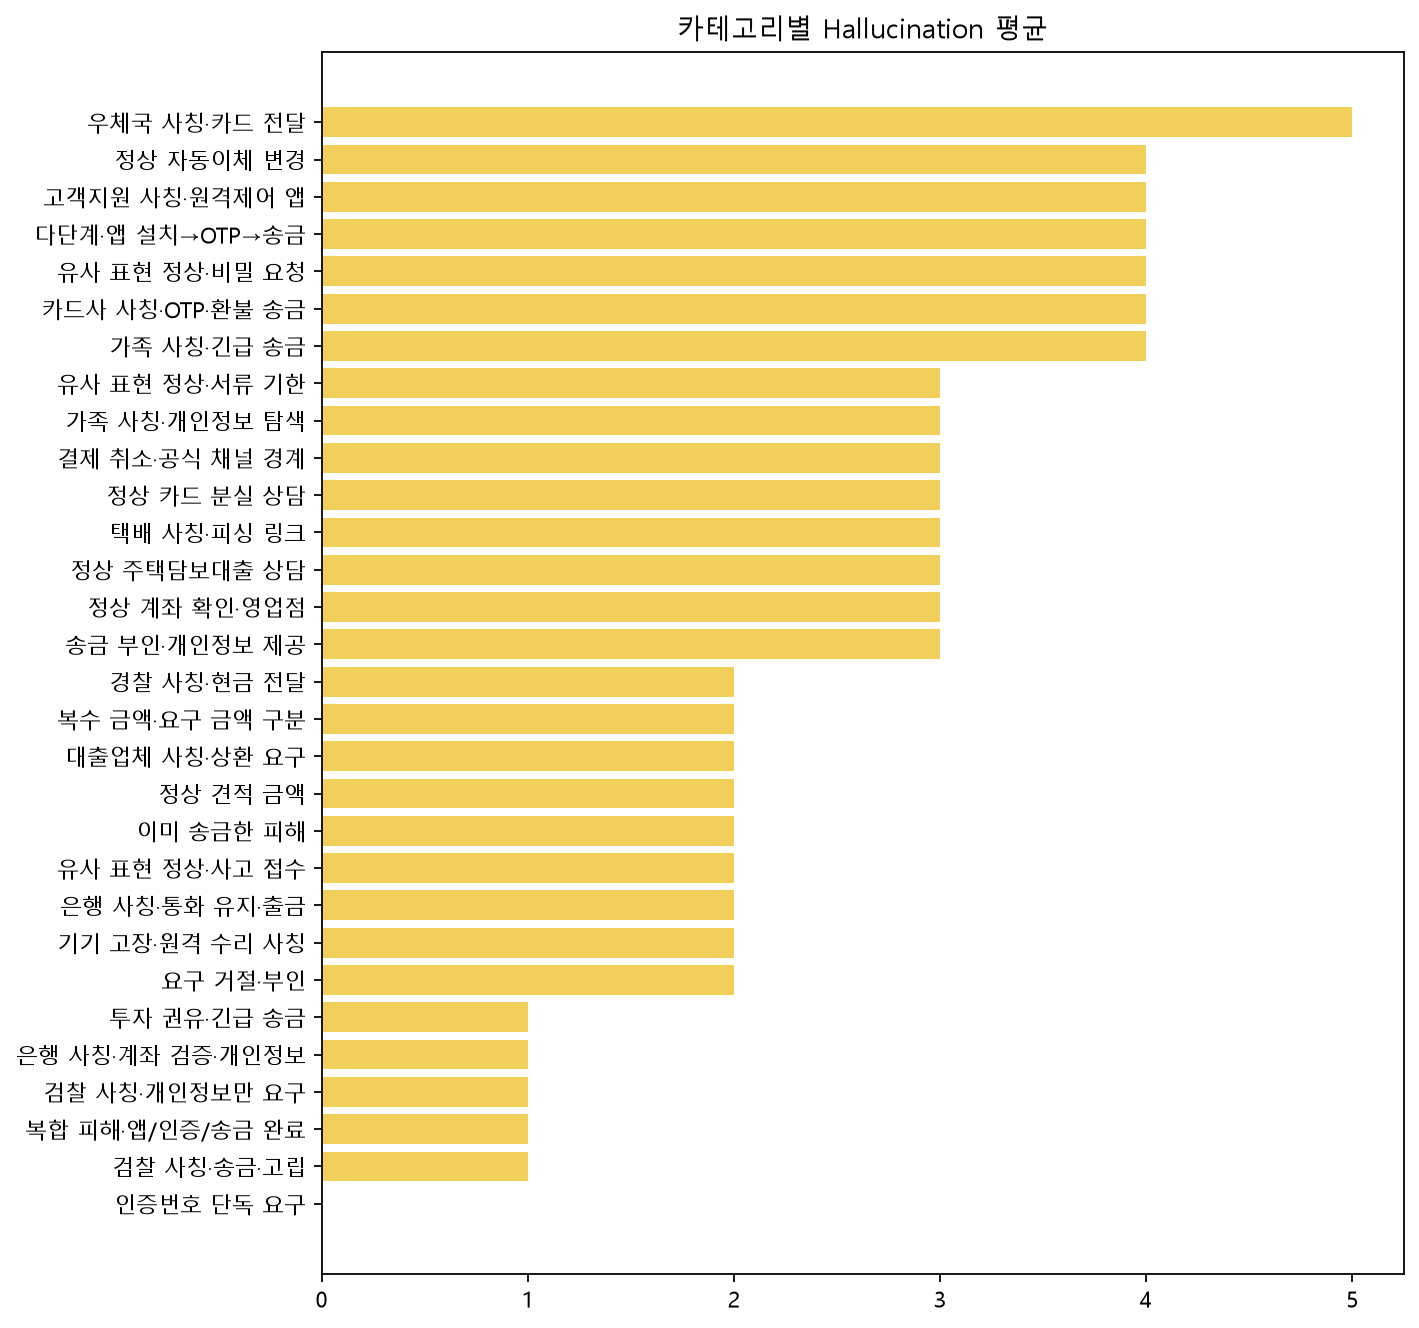

### 06_metric_heatmap

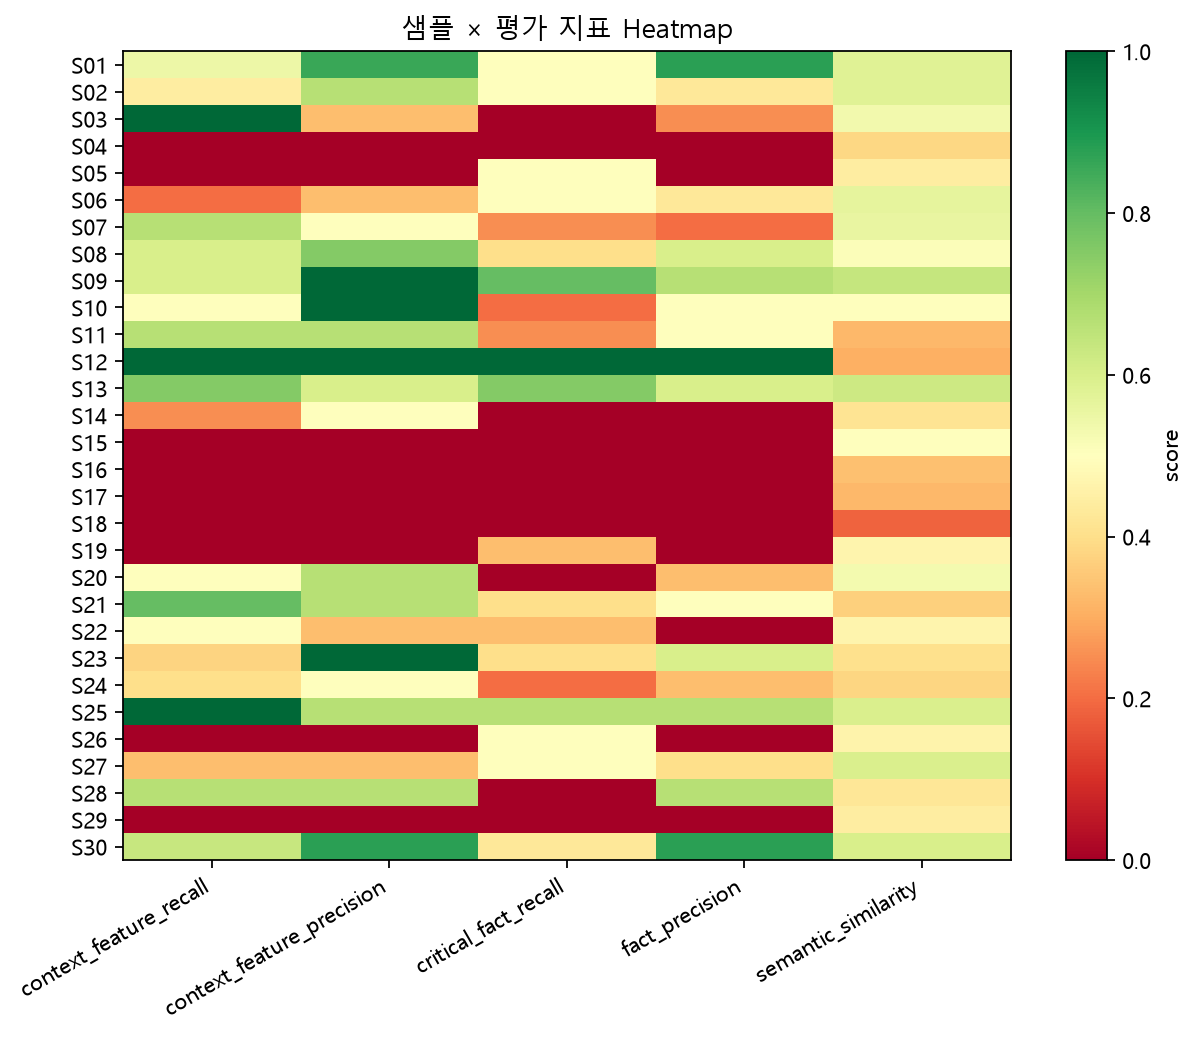

### 07_feature_flow_counts

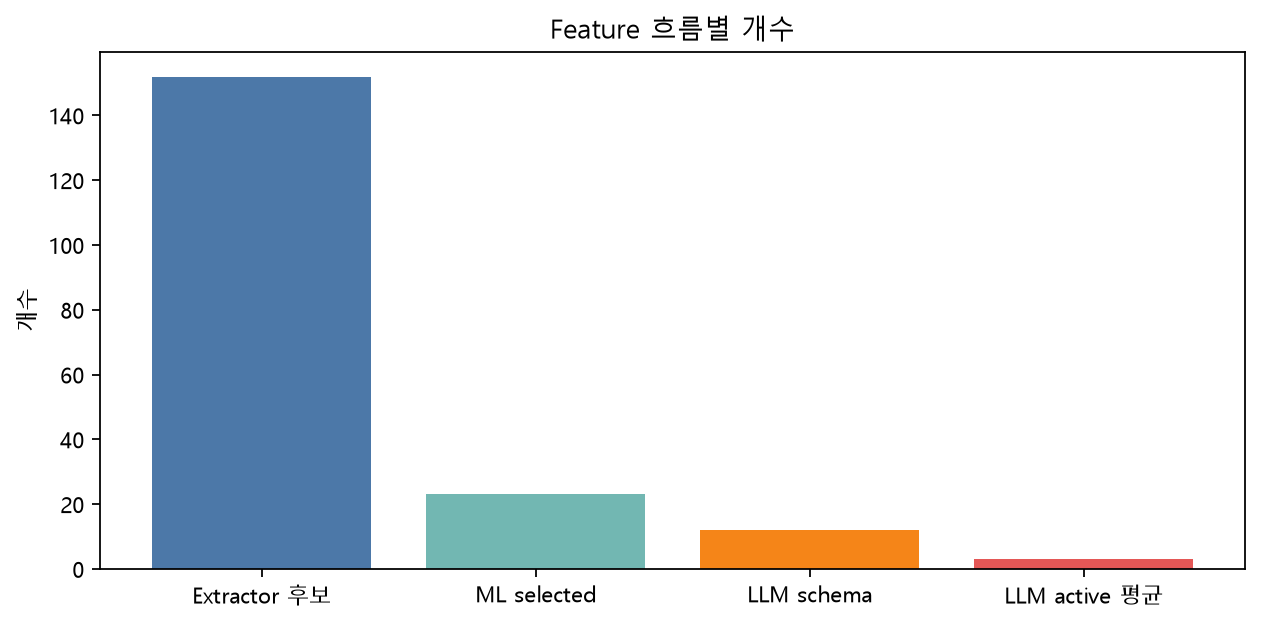

In [8]:
for path in sorted(rv.FIGURE_DIR.glob('*.png')):
    display(Markdown(f'### {path.stem}'))
    display(Image(filename=str(path)))

## 7. 산출물

실행 결과는 `results/context_reconstruction/` 아래 CSV/JSON/Markdown 및 PNG로 저장되며, PPT용 Feature 표는 `docs/context_feature_inventory_ko.md`에 생성된다. 상세 결론과 실패 조건은 summary 파일을 기준으로 한다.

In [9]:
display(Markdown((rv.RESULT_DIR / 'context_reconstruction_summary.md').read_text(encoding='utf-8')))

# Context Reconstruction Validation Summary

실행 시각: 2026-09-06T18:03:10.104681+09:00

## 실행 범위

- 총 샘플: 30개 (성공 30 / 실패 0)
- 운영 코드: `DiagnosisService.analyze` → `WindowAiAdapter`/독립 Context Extractor → 실제 model pkl → Context LLM
- DB 기록: 수행하지 않음. 운영 `project_diagnosis_for_case`와 `InitialReportBuilder`까지 실행해 저장 직전 구조를 검증함.
- Embedding: `text-embedding-3-small`
- 검증 카테고리: 가족 사칭·개인정보 탐색, 가족 사칭·긴급 송금, 검찰 사칭·개인정보만 요구, 검찰 사칭·송금·고립, 결제 취소·공식 채널 경계, 경찰 사칭·현금 전달, 고객지원 사칭·원격제어 앱, 기기 고장·원격 수리 사칭, 다단계·앱 설치→OTP→송금, 대출업체 사칭·상환 요구, 복수 금액·요구 금액 구분, 복합 피해·앱/인증/송금 완료, 송금 부인·개인정보 제공, 요구 거절·부인, 우체국 사칭·카드 전달, 유사 표현 정상·비밀 요청, 유사 표현 정상·사고 접수, 유사 표현 정상·서류 기한, 은행 사칭·계좌 검증·개인정보, 은행 사칭·통화 유지·출금, 이미 송금한 피해, 인증번호 단독 요구, 정상 견적 금액, 정상 계좌 확인·영업점, 정상 자동이체 변경, 정상 주택담보대출 상담, 정상 카드 분실 상담, 카드사 사칭·OTP·환불 송금, 택배 사칭·피싱 링크, 투자 권유·긴급 송금

## 핵심 Runtime 수치

- Extractor 후보 Feature: **152개**
- ML selected Feature: **23개** (0값도 모두 모델 DataFrame에 전달)
- LLM `case_context_features` schema: **12개 필드** (빈 목록 포함 직렬화)
- LLM에 전달되는 숫자 Feature/ML 벡터: **0개**
- LLM 전체 payload 경로 슬롯: **23개(컨테이너 포함), leaf 21개**
- 샘플당 active Context code 평균: **3.23개**
- 실제 예시 `S01`: active 숫자 Feature **7개**, active Context code **7개**, ML selected 23개 중 0값 **20개**

## 최종 우선순위 평가

| 우선순위 | 결과 | 해석 |
| --- | ---: | --- |
| Contradiction | 7 | 금지 사실이 Brief에 나타난 건수 |
| Critical Fact Recall | 0.3137 | 높을수록 좋음 |
| Hallucination | 76 | 비근거 코드·금액 건수 |
| Feature Extraction | 0.4145 | Context code recall |
| Semantic Similarity | 0.4679 | 참조 Brief와 embedding cosine |

## 전체 지표

| 지표 | 평균 |
| --- | ---: |
| Context Feature Recall | 0.4145 |
| Context Feature Precision | 0.4638 |
| Numeric Feature Recall | 0.2359 |
| Numeric Feature Precision | 0.4495 |
| Entity Recall | 0.7667 |
| Amount Recall | 0.9667 |
| Critical Fact Recall | 0.3137 |
| Fact Precision | 0.3475 |
| Semantic Similarity | 0.4679 |

## 가장 크게 누락된 정보

| 누락 핵심 사실                 |   샘플 수 |
|:-------------------------------|----------:|
| 통화 유지                      |         3 |
| 은행 사칭                      |         2 |
| 즉시 요구                      |         2 |
| 송금 요구                      |         2 |
| 송금하지 않음                  |         2 |
| 오늘 또는 즉시 처리            |         1 |
| 가족·은행에 알리지 말라는 고립 |         1 |
| 통화 유지 요구                 |         1 |
| 환불 명목 송금 요구            |         1 |
| 은행 문의 차단                 |         1 |

## Risk 경계 오류

- 정상 Ground Truth 9건 중 HIGH 판정: **3건** (S03, S04, S22)
- 위험 Ground Truth 21건 중 HIGH 미달: **12건** (S01, S10, S11, S12, S13, S14, S15, S20, S24, S25, S27, S29)

## 샘플별 결과

| sample_id   | category                     | risk_level   |   risk_score |   context_feature_recall |   critical_fact_recall |   fact_precision |   hallucination_count |   contradiction_count | amount_preservation   |   semantic_similarity |
|:------------|:-----------------------------|:-------------|-------------:|-------------------------:|-----------------------:|-----------------:|----------------------:|----------------------:|:----------------------|----------------------:|
| S01         | 검찰 사칭·송금·고립          | NORMAL       |      87.2058 |                 0.545455 |               0.5      |         0.875    |                     1 |                     0 | True                  |              0.580378 |
| S02         | 카드사 사칭·OTP·환불 송금    | HIGH         |      95.3573 |                 0.444444 |               0.5      |         0.428571 |                     4 |                     0 | True                  |              0.580685 |
| S03         | 정상 카드 분실 상담          | HIGH         |      99.0083 |                 1        |               0        |         0.25     |                     3 |                     0 | True                  |              0.532853 |
| S04         | 정상 주택담보대출 상담       | HIGH         |      98.6428 |                 0        |               0        |         0        |                     3 |                     1 | True                  |              0.383621 |
| S05         | 정상 자동이체 변경           | NORMAL       |      68.8253 |                 0        |               0.5      |         0        |                     4 |                     2 | True                  |              0.441759 |
| S06         | 가족 사칭·긴급 송금          | HIGH         |      99.1076 |                 0.2      |               0.5      |         0.428571 |                     4 |                     0 | True                  |              0.563082 |
| S07         | 고객지원 사칭·원격제어 앱    | HIGH         |      99.9761 |                 0.666667 |               0.25     |         0.2      |                     4 |                     0 | True                  |              0.555217 |
| S08         | 경찰 사칭·현금 전달          | HIGH         |      99.9428 |                 0.6      |               0.4      |         0.6      |                     2 |                     0 | False                 |              0.511352 |
| S09         | 대출업체 사칭·상환 요구      | HIGH         |      98.6428 |                 0.6      |               0.8      |         0.666667 |                     2 |                     0 | False                 |              0.636852 |
| S10         | 은행 사칭·계좌 검증·개인정보 | NORMAL       |       4.3118 |                 0.5      |               0.2      |         0.5      |                     1 |                     0 | True                  |              0.497058 |
| S11         | 택배 사칭·피싱 링크          | NORMAL       |      90.0927 |                 0.666667 |               0.25     |         0.5      |                     3 |                     0 | True                  |              0.322316 |
| S12         | 인증번호 단독 요구           | NORMAL       |      66.8821 |                 1        |               1        |         1        |                     0 |                     0 | True                  |              0.308558 |
| S13         | 이미 송금한 피해             | NORMAL       |      90.0927 |                 0.75     |               0.75     |         0.6      |                     2 |                     0 | False                 |              0.623419 |
| S14         | 송금 부인·개인정보 제공      | NORMAL       |       4.3118 |                 0.25     |               0        |         0        |                     3 |                     0 | True                  |              0.416281 |
| S15         | 요구 거절·부인               | NORMAL       |      68.8253 |                 0        |               0        |         0        |                     2 |                     0 | True                  |              0.502034 |
| S16         | 유사 표현 정상·서류 기한     | NORMAL       |      68.8253 |                 0        |               0        |         0        |                     3 |                     0 | True                  |              0.338222 |
| S17         | 유사 표현 정상·사고 접수     | NORMAL       |      68.8253 |                 0        |               0        |         0        |                     2 |                     1 | True                  |              0.320443 |
| S18         | 유사 표현 정상·비밀 요청     | NORMAL       |      90.0927 |                 0        |               0        |         0        |                     4 |                     1 | True                  |              0.185958 |
| S19         | 정상 견적 금액               | NORMAL       |      68.8253 |                 0        |               0.333333 |         0        |                     2 |                     0 | True                  |              0.468727 |
| S20         | 복수 금액·요구 금액 구분     | NORMAL       |      20      |                 0.5      |               0        |         0.333333 |                     2 |                     0 | True                  |              0.528021 |
| S21         | 다단계·앱 설치→OTP→송금      | HIGH         |      99.8438 |                 0.8      |               0.4      |         0.5      |                     4 |                     0 | False                 |              0.37075  |
| S22         | 결제 취소·공식 채널 경계     | HIGH         |      96.4238 |                 0.5      |               0.333333 |         0        |                     3 |                     1 | False                 |              0.466596 |
| S23         | 기기 고장·원격 수리 사칭     | HIGH         |      99.6397 |                 0.375    |               0.4      |         0.6      |                     2 |                     0 | True                  |              0.405312 |
| S24         | 은행 사칭·통화 유지·출금     | NORMAL       |      35.4971 |                 0.4      |               0.2      |         0.333333 |                     2 |                     0 | False                 |              0.380813 |
| S25         | 검찰 사칭·개인정보만 요구    | NORMAL       |      90.3537 |                 1        |               0.666667 |         0.666667 |                     1 |                     0 | True                  |              0.594921 |
| S26         | 정상 계좌 확인·영업점        | NORMAL       |      73.7175 |                 0        |               0.5      |         0        |                     3 |                     1 | True                  |              0.461462 |
| S27         | 가족 사칭·개인정보 탐색      | NORMAL       |      90.0927 |                 0.333333 |               0.5      |         0.4      |                     3 |                     0 | True                  |              0.5939   |
| S28         | 투자 권유·긴급 송금          | HIGH         |      97.119  |                 0.666667 |               0        |         0.666667 |                     1 |                     0 | False                 |              0.424123 |
| S29         | 우체국 사칭·카드 전달        | NORMAL       |      91.6061 |                 0        |               0        |         0        |                     5 |                     0 | True                  |              0.444297 |
| S30         | 복합 피해·앱/인증/송금 완료  | HIGH         |      99.7779 |                 0.636364 |               0.428571 |         0.875    |                     1 |                     0 | False                 |              0.598315 |

## 대표 샘플 5건 상세 비교

### S03 — 정상 카드 분실 상담

- 원문: 체크카드를 분실해서 사용 정지를 요청하려고 합니다. / 즉시 카드 사용을 정지하고 최근 승인 내역을 확인하겠습니다. / 어제 편의점 결제 이후에는 제가 사용한 내역이 아닙니다. / 해당 거래는 이의 신청으로 접수하고 새 카드를 재발급하겠습니다. / 접수번호는 공식 앱 알림으로 확인하실 수 있습니다.
- Ground Truth: 정상 카드 분실 상담, 공식 앱 확인
- 구조화 Context: CLAIM_DEVICE_BROKEN, CLAIM_UNAUTHORIZED_PAYMENT, NORMAL_CARD_CONSULTATION
- 생성 Brief: 해당 사건은 카드 관련 문제를 주장하는 것으로, 주요 요청은 기기 고장과 비인가 결제에 대한 것입니다. 여러 차례 정상 카드 상담 요청이 들어왔으나, 비인가 결제 주장으로 인해 신뢰성 문제가 발생하였습니다.
- 누락: 정상 카드 분실 상담, 공식 앱 확인
- 모순: 없음
### S04 — 정상 주택담보대출 상담

- 원문: 주택담보대출 금리와 준비 서류를 상담받고 싶습니다. / 소득과 담보 조건에 따라 적용 금리가 달라질 수 있습니다. / 필요 서류 목록을 은행 공식 앱 상담함으로 보내드리겠습니다. / 서류 제출 전 예상 한도 조회도 가능합니다. / 검토 후 영업점 방문 일정을 예약해 드리겠습니다.
- Ground Truth: 정상 대출 상담, 공식 앱, 영업점 방문
- 구조화 Context: NORMAL_DAILY_CALL
- 생성 Brief: 금융 기관을 사칭하는 사건이 발생했습니다. 여러 차례의 고위험 요청이 있었습니다. 다양한 용도로 정상적인 일상 통화가 요청되었습니다.
- 누락: 정상 대출 상담, 공식 앱, 영업점 방문
- 모순: 기관 사칭
### S14 — 송금 부인·개인정보 제공

- 원문: 은행 직원이라는 사람이 송금을 요구했지만 돈은 보내지 않았습니다. / 다만 주민등록번호와 계좌번호는 알려 줬습니다.
- Ground Truth: 은행 직원 사칭, 송금 요구, 송금하지 않음, 개인정보 제공함
- 구조화 Context: CLAIM_ACCOUNT_VERIFICATION, REQUEST_TRANSFER
- 생성 Brief: 해당 사건은 금융기관을 사칭하며 민감한 개인정보를 요구하는 것으로 의심되는 사례입니다.
- 누락: 은행 직원 사칭, 송금 요구, 송금하지 않음, 개인정보 제공함
- 모순: 없음
### S12 — 인증번호 단독 요구

- 원문: 본인 확인을 위해 방금 받은 여섯 자리 인증번호를 알려 주세요.
- Ground Truth: 인증번호 요구
- 구조화 Context: REQUEST_AUTH_INFO
- 생성 Brief: Psy Strategy와 관련된 신호가 발생했습니다. 요청된 행동은 인증 정보 요청으로, 권위적인 접근 방식을 사용했을 가능성이 있습니다.
- 누락: 없음
- 모순: 없음
### S09 — 대출업체 사칭·상환 요구

- 원문: 저금리 대환대출 승인이 났습니다. 기존 대출금을 먼저 상환해야 실행됩니다. / 오늘 오후까지 800만원을 지정 계좌로 갚으시면 됩니다.
- Ground Truth: 대출업체 사칭, 대환대출 승인 주장, 기존 대출 상환 명목, 800만원, 오늘 기한
- 구조화 Context: CLAIM_LOAN_APPROVAL, DEADLINE_TODAY, PURPOSE_LOAN_REPAYMENT
- 생성 Brief: 이 사건은 금융 기관을 사칭한 대출 승인을 요구하는 신호가 발견되었으며, 대출 상환을 위한 자금 이체 요청이 있었습니다. 요청은 오늘 마감 기한이 있어 높은 위험도가 나타납니다.
- 누락: 800만원
- 모순: 없음


## 오류 샘플

없음

## 그래프

- `results\context_reconstruction\figures\01_feature_recall_by_sample.png`
- `results\context_reconstruction\figures\02_feature_recall_by_category.png`
- `results\context_reconstruction\figures\03_frequently_missing_facts.png`
- `results\context_reconstruction\figures\04_context_vs_brief.png`
- `results\context_reconstruction\figures\05_hallucination_by_category.png`
- `results\context_reconstruction\figures\06_metric_heatmap.png`
- `results\context_reconstruction\figures\07_feature_flow_counts.png`

## 평가 해석상 주의

- Feature precision/recall은 Ground Truth에 명시한 핵심 active 신호와 실제 representative-window active 신호를 비교합니다. 파생 count·QC·interaction Feature는 inventory에는 포함하지만 이 점수의 분모에서는 제외합니다.
- Brief 핵심 사실/모순/Hallucination은 고정된 한국어 키워드·금액 규칙 기반 감사입니다. LLM judge를 추가로 호출하지 않아 재현 가능하지만, 완전한 의미 판정은 아닙니다.
- Semantic similarity는 의미적 유사성만 보며 사실 정확성을 보장하지 않습니다. 따라서 최종 우선순위에서 가장 낮게 둡니다.
- 독립 Context Extractor의 33개 code vocabulary 중 active 관찰만 배열에 담기며, 비활성 code를 0으로 보내지는 않습니다. 반대로 12개 필드 자체와 기본 빈 배열은 모두 LLM payload에 포함됩니다.
- 호출 결과는 LLM 비결정성의 영향을 받을 수 있으며, 본 결과는 위 실행 시각의 단일 run입니다.

## PPT에 바로 사용할 수 있는 결론

| 질문 | Runtime 검증 결론 |
| --- | --- |
| Feature Extractor는 무엇을 만드는가? | Window별 숫자 후보 152개를 계산합니다. |
| ML은 무엇을 받는가? | 고정 순서 23개 selected Feature를 받으며, 값이 0이어도 열에서 제거하지 않습니다. |
| LLM은 숫자 Feature를 받는가? | 받지 않습니다. 숫자 152개/selected 23개 중 LLM 직접 입력은 0개입니다. |
| LLM이 받는 Context는 몇 개인가? | `case_context_features` 12개 필드입니다. 전체 요청 schema는 top-level 4 + signal 속성 7 + nested 12 = 23개 슬롯입니다. |
| 비활성 Feature는 전달되는가? | Context code는 active 관찰만 배열에 포함합니다. 다만 빈 배열을 포함한 12개 필드 자체는 모두 전달됩니다. |
| initial_brief 연결은? | HIGH Case에서 `ContextResult.summary`가 그대로 `initial_brief`와 초기 리포트 summary가 됩니다. NORMAL은 Case를 만들지 않고 고정 안내문을 반환합니다. |
| Shared Case에는 원문이 남는가? | `input_text`는 빈 문자열이며, event evidence와 window text는 저장 전 안전 라벨로 치환됩니다. |
| 현재 품질 결론 | Context Feature Recall 0.414, 핵심 사실 Recall 0.314로 PPT에서 “완성”보다 “구조는 구현됐으나 재구성 품질 개선 필요”로 표현해야 합니다. |

## 코드 개선 제안 (본 작업에서는 미적용)

1. Event/Context instruction의 정상·부인·완료 상태 구분을 강화하고 prompt 회귀 테스트를 추가합니다.
2. 독립 Context Extractor가 `PURPOSE_`, `DEADLINE_`, `CUSTOMER_`, `NORMAL_`을 direct 배열에서 버리지 않도록 명시 필드를 추가하거나 `observations` 소비를 강제합니다.
3. `amount_values_krw`가 현재 독립 추출 경로에서 항상 빈 배열인 단절을 해소하고, event 금액과 요구 금액을 구분해 Context LLM에 전달합니다.
4. `DENIED`/`REPORTED`/`REQUESTED` 상태를 Brief 템플릿의 필수 문장으로 만들어 “요구”와 “이미 수행”의 혼동을 막습니다.
5. 정상 상담 hard-negative와 개인정보·현금전달·단일 인증번호 사례를 모델 재학습/threshold calibration 세트에 포함합니다.
6. 핵심 사실은 자유 생성 summary에만 맡기지 말고 구조화 관찰에서 결정적으로 렌더링한 뒤 LLM이 문장만 다듬도록 합니다.
7. 본 30개 세트를 CI의 외부-LLM 비정기 eval과 고정 fixture 기반 회귀 테스트로 분리해 운영합니다.
